# 05 — Tổng hợp kết quả, ablation và phân tích lỗi

Notebook này **không train gì cả** — chỉ đọc kết quả từ `outputs/logs/` và sinh ra
toàn bộ bảng/hình cho các chương cuối của báo cáo:

- Kết quả định lượng chính (so sánh 4 mô hình)
- Kết quả theo lớp và theo nhóm dữ liệu
- Kết quả ablation
- So sánh các họ kiến trúc
- Phân tích lỗi
- Chi phí tính toán

**Điều kiện:** đã chạy notebook 01–04. Cần file dự đoán trong
`outputs/logs/predictions/*.npy`. Notebook 04 tự lưu; với 02 và 03 hãy thêm cell:

```python
pred_dir = os.path.join(LOG_DIR, "predictions"); os.makedirs(pred_dir, exist_ok=True)
for name, r in RESULTS.items():
    np.save(os.path.join(pred_dir, f"{name}.npy"), r["_preds"][1])
np.save(os.path.join(pred_dir, "y_true.npy"), RESULTS[list(RESULTS)[0]]["_preds"][0])
```

## Setup Kaggle — kéo code từ GitHub

Chạy cell này **trước tiên** trên Kaggle. Bỏ qua được khi chạy ở máy local.
Sửa code ở máy → `git push` → chạy lại cell này để lấy bản mới.

In [1]:
import os

REPO_URL = "https://github.com/dofu18/ViANLI_DL_NLP.git"

if os.path.exists("/kaggle/input"):
    !rm -rf /kaggle/working/repo
    !git clone -q $REPO_URL /kaggle/working/repo
    !cp -r /kaggle/working/repo/src /kaggle/working/
    !cp -r /kaggle/working/repo/configs /kaggle/working/
    !cp -r /kaggle/working/repo/data /kaggle/working/     # split cố định từ 01_eda
    print("src/:", sorted(os.listdir("/kaggle/working/src")))
else:
    print("Chạy local — bỏ qua bước clone.")

Chạy local — bỏ qua bước clone.


In [2]:
import glob, json, os, sys, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ON_KAGGLE = os.path.exists("/kaggle/input")
ROOT = "/kaggle/working" if ON_KAGGLE else os.path.abspath("..")
sys.path.insert(0, os.path.join(ROOT, "src"))

FIG_DIR = os.path.join(ROOT, "outputs", "figures")
LOG_DIR = os.path.join(ROOT, "outputs", "logs")
PRED_DIR = os.path.join(LOG_DIR, "predictions")
os.makedirs(FIG_DIR, exist_ok=True)

from data import LABELS, normalize

pd.set_option("display.max_colwidth", 110)
print("ROOT =", ROOT)

ROOT = D:\NLP


## 1. Gom kết quả

Đọc mọi `*_summary.json` thay vì phụ thuộc vào thứ tự chạy notebook.

In [3]:
rows = []
for path in sorted(glob.glob(os.path.join(LOG_DIR, "*_summary.json"))):
    with open(path, encoding="utf-8") as f:
        d = json.load(f)
    d.pop("config", None)
    rows.append(d)

assert rows, "Chưa có file *_summary.json — chạy notebook 02/03/04 trước"
results = pd.DataFrame(rows).drop_duplicates("run_name").set_index("run_name")
# nb 02/03/04 ghi tập khoá hơi khác nhau -> đảm bảo mọi cột dùng ở dưới đều tồn tại
for col in ("model_id", "arch", "epochs_chạy", "inference_ms_per_sample",
            "peak_vram_gb", "train_seconds", "params"):
    if col not in results.columns:
        results[col] = pd.NA
results.round(4)

,arch,accuracy,macro_f1,weighted_f1,params,epochs_chạy,train_seconds,word_segment,model_id,inference_ms_per_sample,peak_vram_gb
run_name,,,,,,,,,,,
bilstm_attn,bilstm,0.379,0.3659,0.3660,5045848,6,76.7,True,NaN,NaN,NaN
bilstm_dropout02,bilstm,0.403,0.3963,0.3964,5045848,6,76.0,True,NaN,NaN,NaN
bilstm_hyponly,bilstm,0.351,0.3405,0.3406,5045848,7,53.3,True,NaN,NaN,NaN
bilstm_maxlen64,bilstm,0.380,0.3621,0.3622,5045848,6,71.6,True,NaN,NaN,NaN
phobert_base_v2,NaN,0.470,0.4659,0.4660,135000579,8,655.7,True,vinai/phobert-base-v2,3.02,3.98
phobert_hyponly,NaN,0.416,0.4093,0.4093,135000579,6,281.1,True,vinai/phobert-base-v2,1.62,2.78
phobert_lr5e-5,NaN,0.450,0.4479,0.4479,135000579,6,493.8,True,vinai/phobert-base-v2,3.01,3.98
phobert_no_wordseg,NaN,0.421,0.4209,0.4210,135000579,8,771.8,False,vinai/phobert-base-v2,3.49,4.00
textcnn,textcnn,0.334,0.3274,0.3275,4440663,9,112.4,True,NaN,NaN,NaN


In [4]:
# Phân loại mỗi lần chạy: mô hình chính hay nhánh ablation
MAIN = {
    "textcnn": "1. CNN-based (TextCNN)",
    "bilstm_attn": "2. RNN-based (BiLSTM+attn)",
    "phobert_base_v2": "3. Transformer (PhoBERT)",
    "xlmr_large_finetuned": "4. External (XLM-R large)",
}
missing = [k for k in MAIN if k not in results.index]
if missing:
    print("CẢNH BÁO — thiếu kết quả của:", missing)

main_tbl = (results.loc[[k for k in MAIN if k in results.index]]
            .rename(index=MAIN).sort_index())
ablation_tbl = results.drop(index=[k for k in MAIN if k in results.index])
display(main_tbl.round(4))

,arch,accuracy,macro_f1,weighted_f1,params,epochs_chạy,train_seconds,word_segment,model_id,inference_ms_per_sample,peak_vram_gb
run_name,,,,,,,,,,,
1. CNN-based (TextCNN),textcnn,0.334,0.3274,0.3275,4440663,9,112.4,True,NaN,NaN,NaN
2. RNN-based (BiLSTM+attn),bilstm,0.379,0.3659,0.3660,5045848,6,76.7,True,NaN,NaN,NaN
3. Transformer (PhoBERT),NaN,0.470,0.4659,0.4660,135000579,8,655.7,True,vinai/phobert-base-v2,3.02,3.98
4. External (XLM-R large),NaN,0.449,0.3721,0.3723,559893507,5,2807.2,NaN,xlm-roberta-large,16.23,13.47


## 2. Bảng kết quả chính → LaTeX

Xuất thẳng sang định dạng chép được vào `reports/main.tex`.

In [5]:
def fmt_params(n):
    return f"{n / 1e6:.1f}M" if n >= 1e6 else f"{n / 1e3:.0f}K"

def fmt_time(s):
    return "—" if not s else (f"{s / 60:.1f} phút" if s < 3600 else f"{s / 3600:.2f} giờ")

report_tbl = pd.DataFrame({
    "Accuracy": main_tbl["accuracy"].round(4),
    "Macro-F1": main_tbl["macro_f1"].round(4),
    "Params": main_tbl["params"].map(fmt_params),
    "Train time": main_tbl["train_seconds"].map(fmt_time),
    "Inference (ms/mẫu)": main_tbl.get("inference_ms_per_sample", pd.Series(dtype=float)),
})
display(report_tbl)

print(report_tbl.to_latex(escape=False, na_rep="—",
                          caption="So sánh kết quả chính trên tập test",
                          label="tab:main-results"))

,Accuracy,Macro-F1,Params,Train time,Inference (ms/mẫu)
run_name,,,,,
1. CNN-based (TextCNN),0.334,0.3274,4.4M,1.9 phút,NaN
2. RNN-based (BiLSTM+attn),0.379,0.3659,5.0M,1.3 phút,NaN
3. Transformer (PhoBERT),0.470,0.4659,135.0M,10.9 phút,3.02
4. External (XLM-R large),0.449,0.3721,559.9M,46.8 phút,16.23


\begin{table}
\caption{So sánh kết quả chính trên tập test}
\label{tab:main-results}
\begin{tabular}{lrrllr}
\toprule
 & Accuracy & Macro-F1 & Params & Train time & Inference (ms/mẫu) \\
run_name &  &  &  &  &  \\
\midrule
1. CNN-based (TextCNN) & 0.334000 & 0.327400 & 4.4M & 1.9 phút & — \\
2. RNN-based (BiLSTM+attn) & 0.379000 & 0.365900 & 5.0M & 1.3 phút & — \\
3. Transformer (PhoBERT) & 0.470000 & 0.465900 & 135.0M & 10.9 phút & 3.020000 \\
4. External (XLM-R large) & 0.449000 & 0.372100 & 559.9M & 46.8 phút & 16.230000 \\
\bottomrule
\end{tabular}
\end{table}



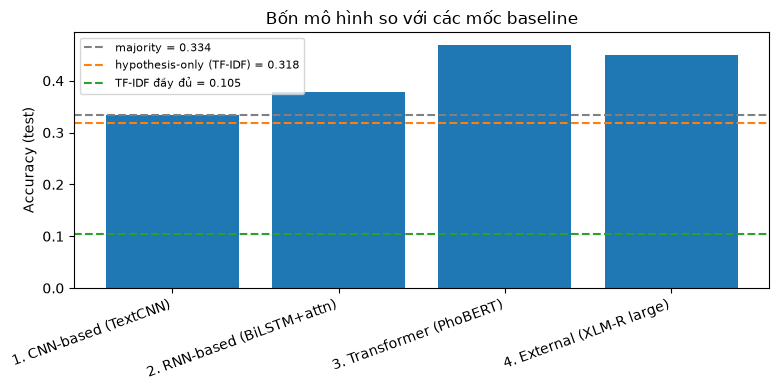

In [6]:
# Biểu đồ cột: accuracy 4 mô hình, kèm các mốc baseline từ 01_eda
eda_path = os.path.join(LOG_DIR, "eda.json")
baselines = {}
if os.path.exists(eda_path):
    with open(eda_path, encoding="utf-8") as f:
        eda = json.load(f)
    baselines = {"majority": eda["majority_baseline_test"],
                 "hypothesis-only (TF-IDF)": eda["baselines"]["hypothesis_only"]["accuracy"],
                 "TF-IDF đầy đủ": eda["baselines"]["full_tfidf"]["accuracy"]}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(main_tbl)), main_tbl["accuracy"], color="tab:blue")
ax.set_xticks(range(len(main_tbl)), main_tbl.index, rotation=20, ha="right")
for i, (color, (name, v)) in enumerate(zip(["gray", "tab:orange", "tab:green"],
                                           baselines.items())):
    ax.axhline(v, ls="--", color=color, label=f"{name} = {v:.3f}")
ax.set_ylabel("Accuracy (test)")
ax.set_title("Bốn mô hình so với các mốc baseline")
if baselines:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "main_comparison.png"), dpi=150)
plt.show()

## 3. Kết quả theo lớp

Đọc `*_test.json` (đã chứa `classification_report` và confusion matrix).

In [7]:
per_class = []
for key, label in MAIN.items():
    path = os.path.join(LOG_DIR, f"{key}_test.json")
    if not os.path.exists(path):
        continue
    with open(path, encoding="utf-8") as f:
        rep = json.load(f)
    for lab in LABELS:
        per_class.append({"Mô hình": label, "Nhãn": lab,
                          "Precision": round(rep["per_class"][lab]["precision"], 4),
                          "Recall": round(rep["per_class"][lab]["recall"], 4),
                          "F1": round(rep["per_class"][lab]["f1-score"], 4),
                          "Support": int(rep["per_class"][lab]["support"])})

per_class_df = pd.DataFrame(per_class)
display(per_class_df.pivot(index="Nhãn", columns="Mô hình", values="F1")
                    .reindex(LABELS))
per_class_df.to_csv(os.path.join(LOG_DIR, "per_class.csv"), index=False)

Mô hình,1. CNN-based (TextCNN),2. RNN-based (BiLSTM+attn),3. Transformer (PhoBERT),4. External (XLM-R large)
Nhãn,,,,
entailment,0.3926,0.4473,0.5525,0.5832
neutral,0.2602,0.3860,0.3968,0.4935
contradiction,0.3294,0.2643,0.4485,0.0395


## 4. Ablation

In [8]:
ABLATION_BASE = {
    # "bilstm_no_pretrained_emb": đã bỏ — baseline vốn dùng embedding ngẫu nhiên
    # (EMB_PATH=None ở nb 02) nên nhánh này không có gì để so sánh.
    "bilstm_hyponly": ("bilstm_attn", "Chỉ dùng hypothesis"),
    "bilstm_dropout02": ("bilstm_attn", "Dropout 0.5 → 0.2"),
    "bilstm_maxlen64": ("bilstm_attn", "max_len 128 → 64"),
    "phobert_no_wordseg": ("phobert_base_v2", "Bỏ tách từ tiếng Việt"),
    "phobert_hyponly": ("phobert_base_v2", "Chỉ dùng hypothesis"),
    "phobert_lr5e-5": ("phobert_base_v2", "Learning rate 2e-5 → 5e-5"),
    "xlmr_zeroshot": ("xlmr_large_finetuned", "Zero-shot XNLI (không fine-tune)"),
    "xlmr_xnli_finetuned": ("xlmr_large_finetuned", "Khởi tạo từ checkpoint XNLI"),
}

rows = []
for run, (base, desc) in ABLATION_BASE.items():
    if run in results.index and base in results.index:
        rows.append({
            "Thay đổi": desc,
            "Mô hình gốc": base,
            "Acc gốc": round(results.loc[base, "accuracy"], 4),
            "Acc sau thay đổi": round(results.loc[run, "accuracy"], 4),
            "Δ Acc": round(results.loc[run, "accuracy"] - results.loc[base, "accuracy"], 4),
            "Δ Macro-F1": round(results.loc[run, "macro_f1"] - results.loc[base, "macro_f1"], 4),
        })

abl = pd.DataFrame(rows).sort_values("Δ Acc")
display(abl)
abl.to_csv(os.path.join(LOG_DIR, "ablation.csv"), index=False)

chưa_chạy = [r for r in ABLATION_BASE if r not in results.index]
if chưa_chạy:
    print("Nhánh ablation CHƯA chạy (phải ghi rõ trong báo cáo):", chưa_chạy)

,Thay đổi,Mô hình gốc,Acc gốc,Acc sau thay đổi,Δ Acc,Δ Macro-F1
6,Zero-shot XNLI (không fine-tune),xlmr_large_finetuned,0.449,0.334,-0.115,-0.0475
4,Chỉ dùng hypothesis,phobert_base_v2,0.470,0.416,-0.054,-0.0567
3,Bỏ tách từ tiếng Việt,phobert_base_v2,0.470,0.421,-0.049,-0.0450
0,Chỉ dùng hypothesis,bilstm_attn,0.379,0.351,-0.028,-0.0253
7,Khởi tạo từ checkpoint XNLI,xlmr_large_finetuned,0.449,0.423,-0.026,0.0469
5,Learning rate 2e-5 → 5e-5,phobert_base_v2,0.470,0.450,-0.020,-0.0181
2,max_len 128 → 64,bilstm_attn,0.379,0.380,0.001,-0.0037
1,Dropout 0.5 → 0.2,bilstm_attn,0.379,0.403,0.024,0.0304


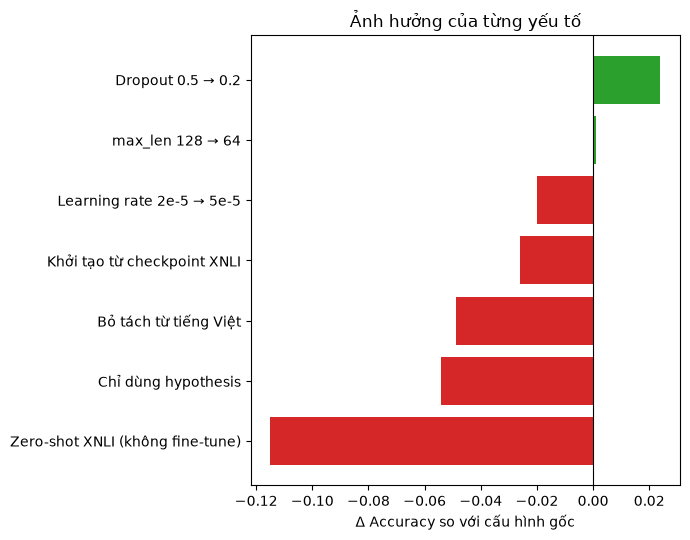

In [9]:
if len(abl):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(abl) + 1.5))
    colors = ["tab:red" if d < 0 else "tab:green" for d in abl["Δ Acc"]]
    ax.barh(abl["Thay đổi"], abl["Δ Acc"], color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Δ Accuracy so với cấu hình gốc")
    ax.set_title("Ảnh hưởng của từng yếu tố")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "ablation.png"), dpi=150)
    plt.show()

## 5. Phân tích lỗi

Từ đây trở xuống cần file dự đoán `.npy`.

In [10]:
test = pd.read_csv(os.path.join(ROOT, "data", "splits", "test.csv"), encoding="utf-8")
test["premise"] = test["premise"].fillna("").map(normalize)
test["hypothesis"] = test["hypothesis"].fillna("").map(normalize)

preds = {}
if os.path.isdir(PRED_DIR):
    for path in glob.glob(os.path.join(PRED_DIR, "*.npy")):
        name = os.path.basename(path)[:-4]
        if name != "y_true":
            preds[name] = np.load(path)

have_preds = bool(preds)
if have_preds:
    y_true = np.load(os.path.join(PRED_DIR, "y_true.npy"))
    assert len(y_true) == len(test), "Dự đoán và test.csv lệch số dòng"
    print("Có dự đoán của:", sorted(preds))
else:
    print("CHƯA có file dự đoán — xem hướng dẫn ở cell đầu notebook. "
          "Các phần dưới sẽ bị bỏ qua.")

Có dự đoán của: ['bilstm_attn', 'bilstm_dropout02', 'bilstm_hyponly', 'bilstm_maxlen64', 'phobert_base_v2', 'phobert_hyponly', 'phobert_lr5e-5', 'phobert_no_wordseg', 'textcnn', 'xlmr_large_finetuned', 'xlmr_xnli_finetuned', 'xlmr_zeroshot']


In [11]:
# Gắn thuộc tính cho từng mẫu test để phân tích lỗi theo nhóm
NEGATION = ["không", "chẳng", "chưa", "đâu có", "không hề", "không bao giờ", "chả"]

def jaccard(p, h):
    a, b = set(p.lower().split()), set(h.lower().split())
    return len(a & b) / max(len(a | b), 1)

test["len_p"] = test["premise"].str.split().str.len()
test["có_phủ_định"] = test["hypothesis"].str.lower().apply(
    lambda h: any(w in h for w in NEGATION))
test["có_số"] = test["hypothesis"].str.contains(r"\d", regex=True)
test["overlap"] = [jaccard(p, h) for p, h in zip(test["premise"], test["hypothesis"])]
test["nhóm_độ_dài"] = pd.qcut(test["len_p"], 3, labels=["ngắn", "trung bình", "dài"])
test["nhóm_overlap"] = pd.qcut(test["overlap"], 3, labels=["thấp", "vừa", "cao"])
test[["có_phủ_định", "có_số"]].mean().round(4)

có_phủ_định    0.161
có_số          0.377
dtype: float64

In [12]:
if have_preds:
    groups = ["nhóm_độ_dài", "nhóm_overlap", "có_phủ_định", "có_số"]
    frames = []
    for key, label in MAIN.items():
        if key not in preds:
            continue
        correct = preds[key] == y_true
        for g in groups:
            acc = pd.Series(correct).groupby(test[g].astype(str)).mean()
            frames.append(acc.rename(label).to_frame().assign(Nhóm=g))
    by_group = (pd.concat(frames).reset_index()
                .rename(columns={"index": "Giá trị"})
                .groupby(["Nhóm", "Giá trị"]).first().round(4))
    display(by_group)
    by_group.to_csv(os.path.join(LOG_DIR, "accuracy_by_group.csv"))

1. CNN-based (TextCNN)  2. RNN-based (BiLSTM+attn)  \
Nhóm         Giá trị                                                          
có_phủ_định  False                       0.3480                      0.3814   
             True                        0.2609                      0.3665   
có_số        False                       0.3387                      0.3692   
             True                        0.3263                      0.3952   
nhóm_overlap cao                         0.2831                      0.3886   
             thấp                        0.3828                      0.4451   
             vừa                         0.3353                      0.3021   
nhóm_độ_dài  dài                         0.3456                      0.3761   
             ngắn                        0.3324                      0.3580   
             trung bình                  0.3240                      0.4050   

                         3. Transformer (PhoBERT)  4. External (XLM-R large)  
Nhóm         Giá trị                                                          
có_phủ_định  False                         0.4708                     0.4529  
             True                          0.4658                     0.4286  
có_số        False                         0.4751                     0.4526  
             True                          0.4615                     0.4430  
nhóm_overlap cao                           0.4307                     0.4488  
             thấp                          0.4985                     0.5015  
             vừa                           0.4804                     0.3958  
nhóm_độ_dài  dài                           0.4801                     0.4128  
             ngắn                          0.4858                     0.4773  
             trung bình                    0.4424                     0.4548

### Các mô hình sai ở cùng chỗ hay khác chỗ?

Nếu tất cả cùng sai trên một tập mẫu, đó là các mẫu adversarial thật sự khó
(hoặc nhãn có vấn đề) — chất liệu tốt cho phần thảo luận.

In [13]:
avail = [k for k in MAIN if k in preds] if have_preds else []

if len(avail) >= 2:
    agree = pd.DataFrame(
        [[float((preds[a] == preds[b]).mean()) for b in avail] for a in avail],
        index=[MAIN[a] for a in avail], columns=[MAIN[b] for b in avail])
    display(agree.round(3))

    wrong_all = np.ones(len(y_true), dtype=bool)
    for k in avail:
        wrong_all &= preds[k] != y_true
    print(f"Số mẫu MỌI mô hình đều sai: {wrong_all.sum()} / {len(y_true)} "
          f"({wrong_all.mean():.1%})")

    right_any = np.zeros(len(y_true), dtype=bool)
    for k in avail:
        right_any |= preds[k] == y_true
    print(f"Số mẫu ÍT NHẤT một mô hình đúng: {right_any.sum()} ({right_any.mean():.1%})")

,1. CNN-based (TextCNN),2. RNN-based (BiLSTM+attn),3. Transformer (PhoBERT),4. External (XLM-R large)
1. CNN-based (TextCNN),1.000,0.500,0.426,0.382
2. RNN-based (BiLSTM+attn),0.500,1.000,0.474,0.563
3. Transformer (PhoBERT),0.426,0.474,1.000,0.501
4. External (XLM-R large),0.382,0.563,0.501,1.000


Số mẫu MỌI mô hình đều sai: 212 / 1000 (21.2%)
Số mẫu ÍT NHẤT một mô hình đúng: 788 (78.8%)


In [14]:
# McNemar test giữa hai mô hình tốt nhất — chênh lệch có ý nghĩa thống kê không?
if len(avail) >= 2:
    from scipy.stats import binomtest

    ranked = sorted(avail, key=lambda k: -results.loc[k, "accuracy"])[:2]
    a, b = ranked
    n01 = int(((preds[a] == y_true) & (preds[b] != y_true)).sum())
    n10 = int(((preds[a] != y_true) & (preds[b] == y_true)).sum())
    p = binomtest(n01, n01 + n10, 0.5).pvalue if n01 + n10 else 1.0
    print(f"McNemar: {MAIN[a]} vs {MAIN[b]}")
    print(f"  chỉ {MAIN[a]} đúng: {n01} | chỉ {MAIN[b]} đúng: {n10} | p = {p:.4g}")
    print("  => " + ("khác biệt có ý nghĩa (p < 0.05)" if p < 0.05
                     else "CHƯA đủ bằng chứng khẳng định mô hình này hơn mô hình kia"))

McNemar: 3. Transformer (PhoBERT) vs 4. External (XLM-R large)
  chỉ 3. Transformer (PhoBERT) đúng: 213 | chỉ 4. External (XLM-R large) đúng: 192 | p = 0.3203
  => CHƯA đủ bằng chứng khẳng định mô hình này hơn mô hình kia


### Bảng ví dụ lỗi cho báo cáo

Lấy các mẫu mà mô hình tốt nhất dự đoán sai, ưu tiên mẫu mà **mọi** mô hình đều sai.
Cột `Nhóm lỗi` để trống — **phải tự đọc và phân loại thủ công** (phủ định, số/định lượng,
kiến thức thế giới, đồng tham chiếu, từ đồng nghĩa, nhãn sai). Đây là phần chấm điểm
chiều sâu, không tự động hóa được.

In [15]:
if avail:
    best = max(avail, key=lambda k: results.loc[k, "accuracy"])
    idx = np.where(preds[best] != y_true)[0]
    if len(avail) >= 2:
        hard = [i for i in idx if wrong_all[i]]
        idx = np.array(hard + [i for i in idx if i not in set(hard)])
    rng = np.random.default_rng(42)
    pick = idx[:12] if len(idx) >= 12 else idx

    err = pd.DataFrame({
        "Premise": test.loc[pick, "premise"].values,
        "Hypothesis": test.loc[pick, "hypothesis"].values,
        "Nhãn thật": [LABELS[i] for i in y_true[pick]],
        **{MAIN[k].split(" (")[0]: [LABELS[i] for i in preds[k][pick]] for k in avail},
        "Nhóm lỗi": "",
    })
    display(err)
    err.to_csv(os.path.join(LOG_DIR, "error_examples.csv"), index=False,
               encoding="utf-8-sig")
    print("Đã ghi outputs/logs/error_examples.csv — mở lên và điền cột 'Nhóm lỗi'")

,Premise,Hypothesis,Nhãn thật,1. CNN-based,2. RNN-based,3. Transformer,4. External,Nhóm lỗi
0,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND phường Mai Động, cho biết lý do phong tỏa là nam sinh 11 tuổi,...",Theo thông tin một công chức Nhà nước ở phường Mai Động đã có ít nhất 11 nam sinh đã bị mắc Covid-19.,contradiction,entailment,entailment,entailment,entailment,
1,"Sau khi xem xét camera giám sát trong khu vực, cảnh sát nhận định nạn nhân đã bị cướp tài sản và sát hại, ...",Cảnh sát đã phán đoán bằng nhận định sắc bén sau khi xem camera an ninh.,neutral,contradiction,entailment,entailment,entailment,
2,"3h sáng cùng ngày, trái tim của của người hiến đã đập lại trong lồng ngực chàng trai.","3am, một người được tái sinh.",contradiction,entailment,entailment,entailment,entailment,
3,"Ông Phạm Cao Vỹ, chủ tịch Hiệp hội Du lịch Sa Pa chia sẻ, nhận được lời kêu gọi từ hiệp hội, rất nhiều doa...",Ông Phạm Cao Vỹ được yêu thích.,neutral,entailment,entailment,entailment,entailment,
4,"Đang nóng ruột vì chưa biết làm thế nào để bay về sớm với hai con gái bị tai nạn, anh Trần Văn Hải bất ngờ...",Anh Trần Văn Hải không có ý định hỏi vé từ một người lạ.,neutral,contradiction,entailment,entailment,entailment,
5,"Ôtô của Nam không dừng lại, lách qua hẹp ở lề đường để đi tiếp song bị cảnh sát hóa trang phục sẵn từ các ...",Nam bị cảnh sát bắt.,neutral,contradiction,contradiction,entailment,entailment,
6,Cảnh sát lập biên bản xử phạt hành chính với chủ cơ sở kinh doanh karaoke vì để khách sử dụng ma túy tại c...,"Sau vụ việc, có người lại được thêm tiền.",contradiction,entailment,entailment,neutral,entailment,
7,"Ở mùa vô địch lần đầu 2017-2018, Guardiola giúp Man City kết thúc giải với 100 điểm.",Guardiola là cầu thủ xuất sắc của Man City.,contradiction,entailment,entailment,entailment,entailment,
8,"Ông cho biết thêm, để được áp dụng khuyến mãi, du khách cần đăng ký đúng đơn vị tham gia chương trình kích...",Khi du khách cần cung cấp thông tin đơn vị tham gia chương trình thì khuyến mãi có thể buộc chuyển cho ngư...,contradiction,neutral,neutral,neutral,entailment,
9,Diện tích đất để xây dựng các loại nhà ở giai đoạn 2020-2025 khoảng 11.796 ha.,Các loại nhà ở giai đoạn 2020-2025 có diện tích khoảng 11.796 ha.,contradiction,neutral,neutral,neutral,neutral,


Đã ghi outputs/logs/error_examples.csv — mở lên và điền cột 'Nhóm lỗi'


## 6. Chi phí tính toán

Accuracy đổi lấy bao nhiêu tài nguyên — luận điểm cho §Chi phí tính toán và khả năng triển khai.

,accuracy,params,train_seconds,inference_ms_per_sample,acc_trên_1M_tham_số
run_name,,,,,
1. CNN-based (TextCNN),0.334,4440663,112.4,NaN,0.0752
2. RNN-based (BiLSTM+attn),0.379,5045848,76.7,NaN,0.0751
3. Transformer (PhoBERT),0.470,135000579,655.7,3.02,0.0035
4. External (XLM-R large),0.449,559893507,2807.2,16.23,0.0008


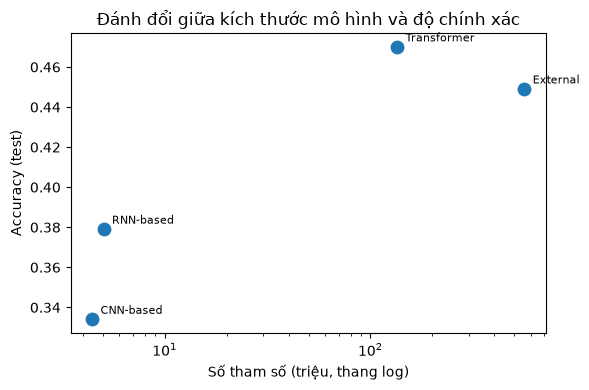

In [16]:
cost = main_tbl[["accuracy", "params", "train_seconds"]].copy()
if "inference_ms_per_sample" in main_tbl:
    cost["inference_ms_per_sample"] = main_tbl["inference_ms_per_sample"]
cost["acc_trên_1M_tham_số"] = (cost["accuracy"] / (cost["params"] / 1e6)).round(5)
display(cost.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(cost["params"] / 1e6, cost["accuracy"], s=80)
for name, r in cost.iterrows():
    ax.annotate(name.split(" ")[1] if " " in name else name,
                (r["params"] / 1e6, r["accuracy"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Số tham số (triệu, thang log)")
ax.set_ylabel("Accuracy (test)")
ax.set_title("Đánh đổi giữa kích thước mô hình và độ chính xác")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cost_vs_accuracy.png"), dpi=150)
plt.show()

## 7. Chốt sổ

Kiểm tra lại những gì đã sinh ra trước khi viết báo cáo.

In [17]:
print("HÌNH trong outputs/figures/:")
for p in sorted(glob.glob(os.path.join(FIG_DIR, "*.png"))):
    print("  ", os.path.basename(p))

print("\nBẢNG trong outputs/logs/:")
for p in sorted(glob.glob(os.path.join(LOG_DIR, "*.csv"))):
    print("  ", os.path.basename(p))

print("\nKiểm tra nhanh:")
print("  Đủ 4 mô hình chính:", len(main_tbl) == 4)
print("  Có ít nhất 1 ablation:", len(abl) >= 1)
print("  Có file dự đoán để phân tích lỗi:", have_preds)
if baselines:
    beat = (main_tbl["accuracy"] > baselines["majority"]).all()
    print("  Mọi mô hình vượt majority baseline:", bool(beat))

HÌNH trong outputs/figures/:
   ablation.png
   bilstm_attn_cm.png
   bilstm_attn_curve.png
   bilstm_dropout02_cm.png
   bilstm_dropout02_curve.png
   bilstm_hyponly_cm.png
   bilstm_hyponly_curve.png
   bilstm_maxlen64_cm.png
   bilstm_maxlen64_curve.png
   cnn_vs_rnn_dev.png
   cost_vs_accuracy.png
   eda_label_dist.png
   eda_length_hist.png
   main_comparison.png
   phobert_base_v2_cm.png
   phobert_base_v2_curve.png
   phobert_hyponly_cm.png
   phobert_hyponly_curve.png
   phobert_lr5e-5_cm.png
   phobert_lr5e-5_curve.png
   phobert_no_wordseg_cm.png
   phobert_no_wordseg_curve.png
   textcnn_cm.png
   textcnn_curve.png
   xlmr_large_finetuned_cm.png
   xlmr_large_finetuned_curve.png
   xlmr_xnli_finetuned_cm.png
   xlmr_xnli_finetuned_curve.png
   xlmr_zeroshot_cm.png

BẢNG trong outputs/logs/:
   ablation.csv
   accuracy_by_group.csv
   cnn_rnn_results.csv
   error_examples.csv
   per_class.csv
   phobert_results.csv
   xlmr_results.csv

Kiểm tra nhanh:
  Đủ 4 mô hình chính: Tr

## Ánh xạ sang các mục của báo cáo

| Mục trong `reports/main.tex` | Nguồn |
|---|---|
| Kết quả định lượng chính | `report_tbl` (đã có sẵn LaTeX), `main_comparison.png` |
| Đường cong huấn luyện | `*_curve.png` từ notebook 02–04 |
| Kết quả theo lớp / nhóm | `per_class.csv`, `accuracy_by_group.csv` |
| Kết quả ablation | `ablation.csv`, `ablation.png` |
| So sánh các họ kiến trúc | bảng chính + McNemar + ma trận đồng thuận |
| Phân tích lỗi | `*_cm.png`, `error_examples.csv` (nhớ điền cột Nhóm lỗi) |
| Chi phí tính toán | `cost` , `cost_vs_accuracy.png` |
| Hạn chế | tỉ lệ mẫu mọi mô hình đều sai, kết quả hypothesis-only, nhánh ablation đã bỏ |

**Nhắc lại:** nếu kết quả thấp so với các bộ NLI thông thường, đó là bản chất của
ViANLI (adversarial). Hãy giải thích bằng số liệu — hypothesis-only baseline, tỉ lệ mẫu
mọi mô hình cùng sai, phân bố lỗi theo nhóm — thay vì cố tinh chỉnh cho đẹp số.